In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 2175.8140
Setting up log_density and prior functions...


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_noise/int_3mth_new_10'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [ ]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.64744637,  0.77905948,  0.70902759,  0.61387778,  0.50824207],
        [ 0.80866587,  1.78306377,  0.7412444 ,  0.47252986,  2.72496411],
        [ 0.99142924,  0.17550986, -0.46539156, -1.18362025,  0.52223498],
        ...,
        [ 0.39582928, -0.30688104,  0.65618595,  0.3721675 ,  0.63617165],
        [ 0.4674937 , -0.47444156,  0.4298598 ,  0.4985281 ,  0.60713848],
        [ 0.91316994,  1.85046606,  0.72948895,  0.26713979,  0.40578508]])]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([170.97065949,         -inf,         -inf, ...,         -inf,
                -inf,         -inf])]

In [ ]:
sampler.now_covariances

[array([[ 0.02023274,  0.09025995, -0.00569585, -0.01268599, -0.0076846 ],
        [ 0.09025995,  0.42402135, -0.0033236 , -0.05375943, -0.03645808],
        [-0.00569585, -0.0033236 ,  0.08091099, -0.01893001, -0.00182497],
        [-0.01268599, -0.05375943, -0.01893001,  0.02431292,  0.0051433 ],
        [-0.0076846 , -0.03645808, -0.00182497,  0.0051433 ,  0.00334706]])]

In [ ]:
np.argmax(logden_list)

71469

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.22080495, 1.26957638, 0.65929287, 8.98412338, 0.3476637 ]])

In [10]:
log_density(maxld_pt1)

array([5.76458854])

In [11]:
log_density([param_true])

array([9.92879914])

In [ ]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

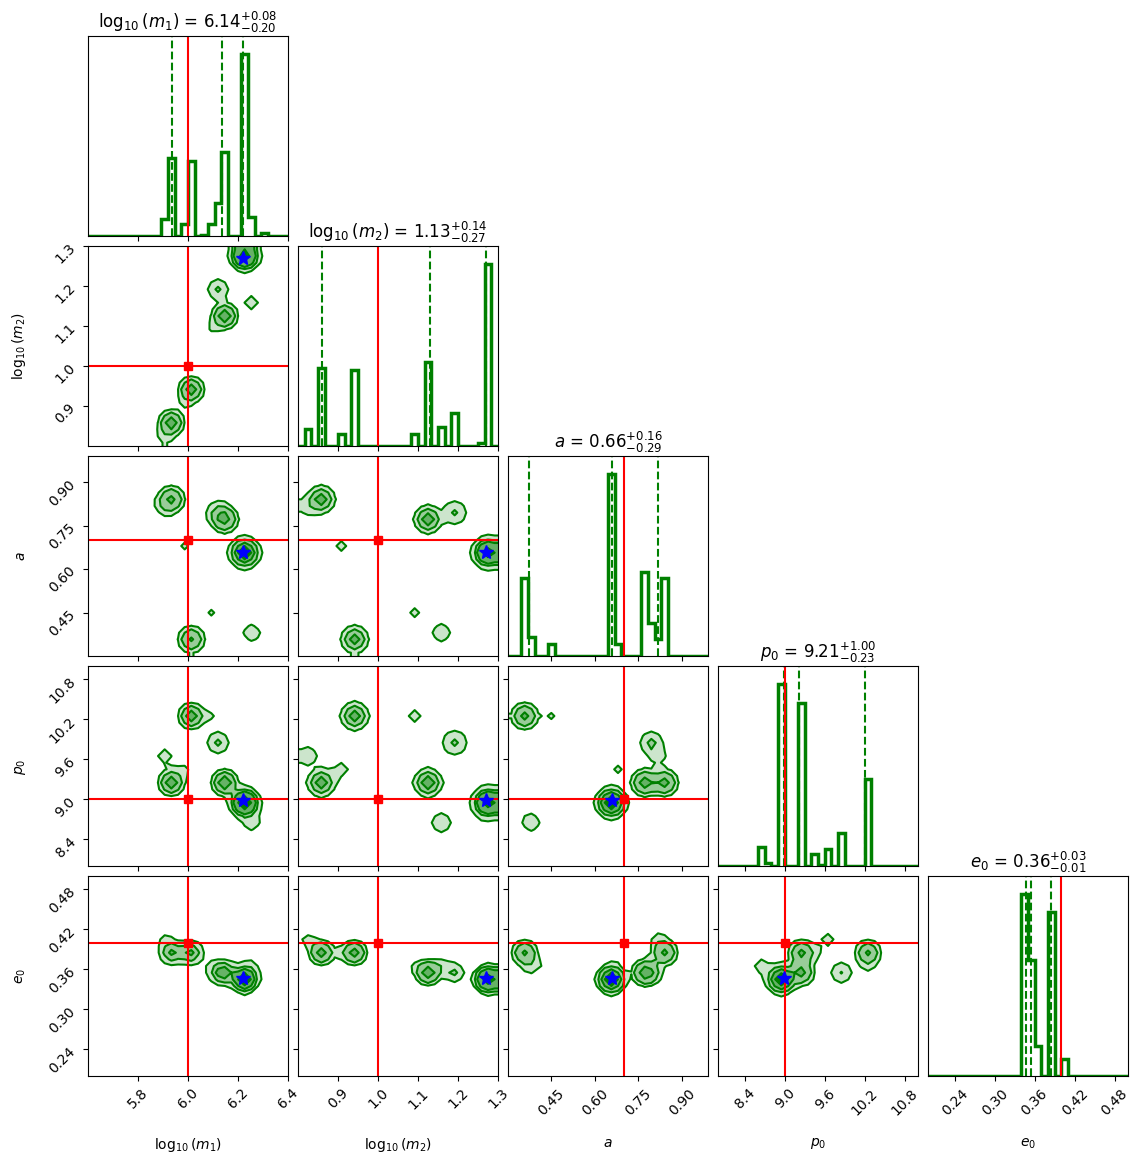

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [ ]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 4.9  (0.00% of N=100000)


# connection plot

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.22080495, 1.26957638, 0.65929287, 8.98412338, 0.3476637 ]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [18]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [20]:
logden_theory_proc1

array([5.76458854, 3.26156661, 2.5444434 , 3.39488148, 2.4033447 ,
       3.13656648, 4.12971741, 3.63843977, 2.98287629, 2.33811718,
       3.2029595 , 2.43933852, 3.41390958, 2.34382562, 3.46526167,
       3.22067828, 2.97332632, 3.23649527, 3.84443219, 2.97169991,
       2.51235387, 3.09490646, 2.57548878, 2.965268  , 2.66232499,
       2.40420585, 2.9205208 , 2.83791286, 3.58841137, 2.98614983,
       2.36168998, 3.2720992 , 2.75923789, 2.46249132, 2.68829794,
       2.2411278 , 2.48503269, 2.93357831, 2.2700787 , 2.26325608,
       3.07585195, 3.20078012, 2.97778368, 2.51115925, 2.43443819,
       2.46695674, 2.2734816 , 2.23289232, 2.83893217, 9.92879914])

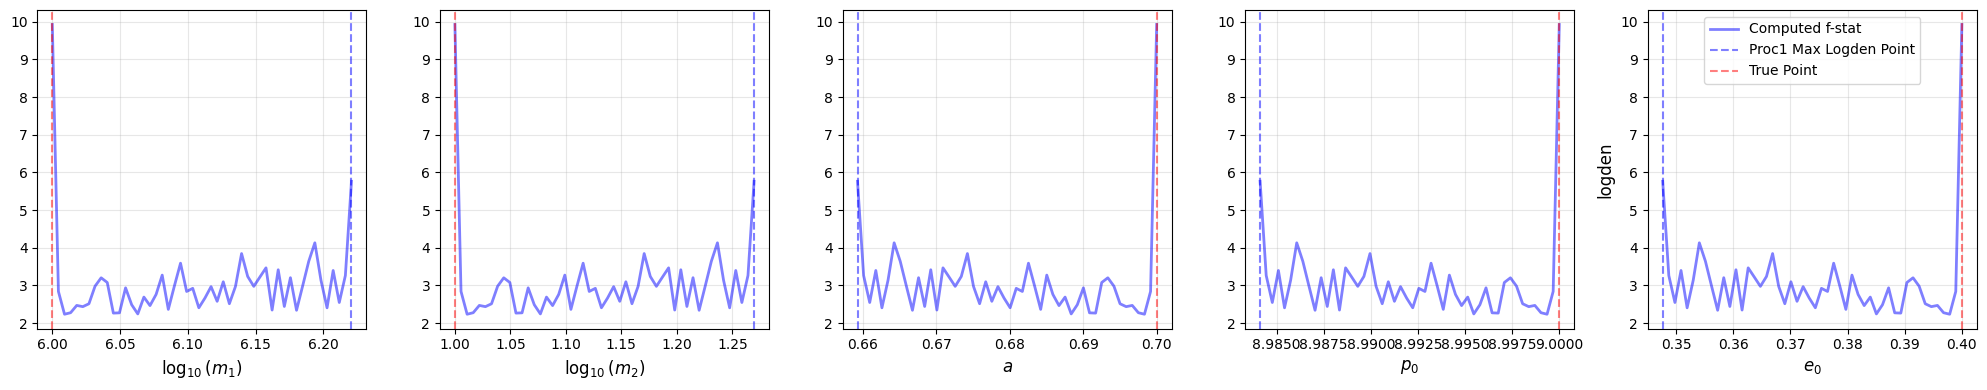

In [21]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
